In [ ]:
!pip install qiskit qiskit-aer pylatexenc matplotlib -q

import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00


In [13]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import numpy as np
import functools

In [14]:
class GroverAlgorithm:
    def __init__(self, num_qubits: int, oracle_function):
        self.num_qubits = num_qubits
        self.oracle_function = oracle_function
        self.qc = QuantumCircuit(num_qubits, num_qubits)

    def _diffuser(self):
        self.qc.h(range(self.num_qubits))
        self.qc.x(range(self.num_qubits))
        self.qc.barrier()
        self.qc.mcp(np.pi, list(range(self.num_qubits - 1)), self.num_qubits - 1)
        self.qc.barrier()
        self.qc.x(range(self.num_qubits))
        self.qc.h(range(self.num_qubits))

    def build_circuit(self, iterations: int = None) -> QuantumCircuit:
        if iterations is None:
            iterations = int(np.floor(np.pi/4 * np.sqrt(2**self.num_qubits)))

        self.qc = QuantumCircuit(self.num_qubits, self.num_qubits)
        self.qc.h(range(self.num_qubits))

        for _ in range(iterations):
            self.qc.barrier()
            self.oracle_function(self.qc, self.num_qubits)
            self.qc.barrier()
            self._diffuser()

        self.qc.measure(range(self.num_qubits), range(self.num_qubits))
        return self.qc

    def draw_pretty(self, circuit=None):
        target = circuit if circuit else self.qc
        return target.draw(output='mpl', style='iqp', scale=0.8)

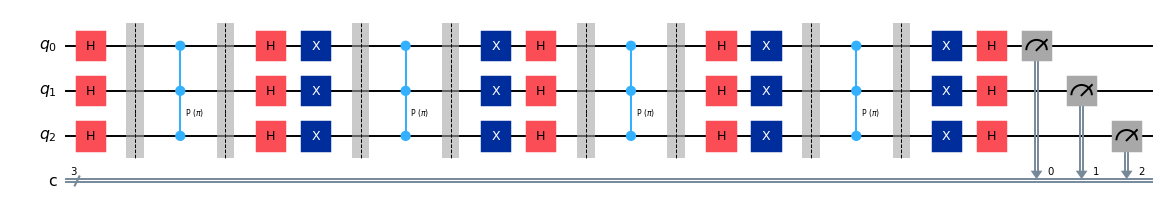

In [15]:
num_qubits = 3

def basic_all_ones_oracle(qc: QuantumCircuit, qbits: int):
    """
    A basic oracle that marks the state |11...1> by shifting its phase by pi.
    """
    control = list(range(qbits - 1))
    target = qbits - 1
    qc.mcp(np.pi, control, target)


grover = GroverAlgorithm(num_qubits=num_qubits, oracle_function=basic_all_ones_oracle)
grover_circuit = grover.build_circuit()

grover_circuit.draw(output="mpl",scale=0.7)

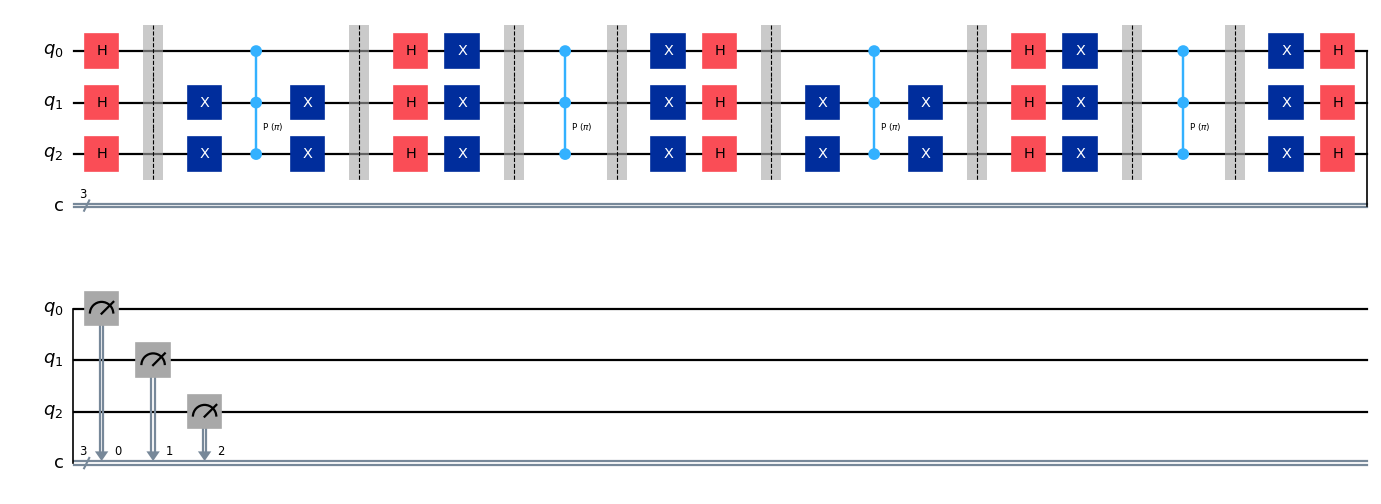

In [16]:
def grover_oracle(func):
    @functools.wraps(func)
    def wrapper(qc, qbits, *args, **kwargs):
        target_binary = func(*args, **kwargs)
        binary_reversed = target_binary[::-1]

        for i, bit in enumerate(binary_reversed):
            if bit == '0': qc.x(i)

        qc.mcp(np.pi, list(range(qbits - 1)), qbits - 1)

        for i, bit in enumerate(binary_reversed):
            if bit == '0': qc.x(i)
    return wrapper

@grover_oracle
def get_target(search_term, database):
    idx = database.index(search_term)
    return format(idx, f'0{int(np.log2(len(database)))}b')

# Example usage with database search
database = ["apple", "banana", "cherry", "date", "elderberry", "fig", "grape", "honeydew"]
search_term = "banana"
oracle_fn = lambda qc, qbits: get_target(qc, qbits, search_term, database)

grover_db = GroverAlgorithm(num_qubits=3, oracle_function=oracle_fn)
db_circuit = grover_db.build_circuit()
grover_db.draw_pretty()

--- Quantum PIN Cracker Setup ---
Target PIN: 6 | Binary: 0110


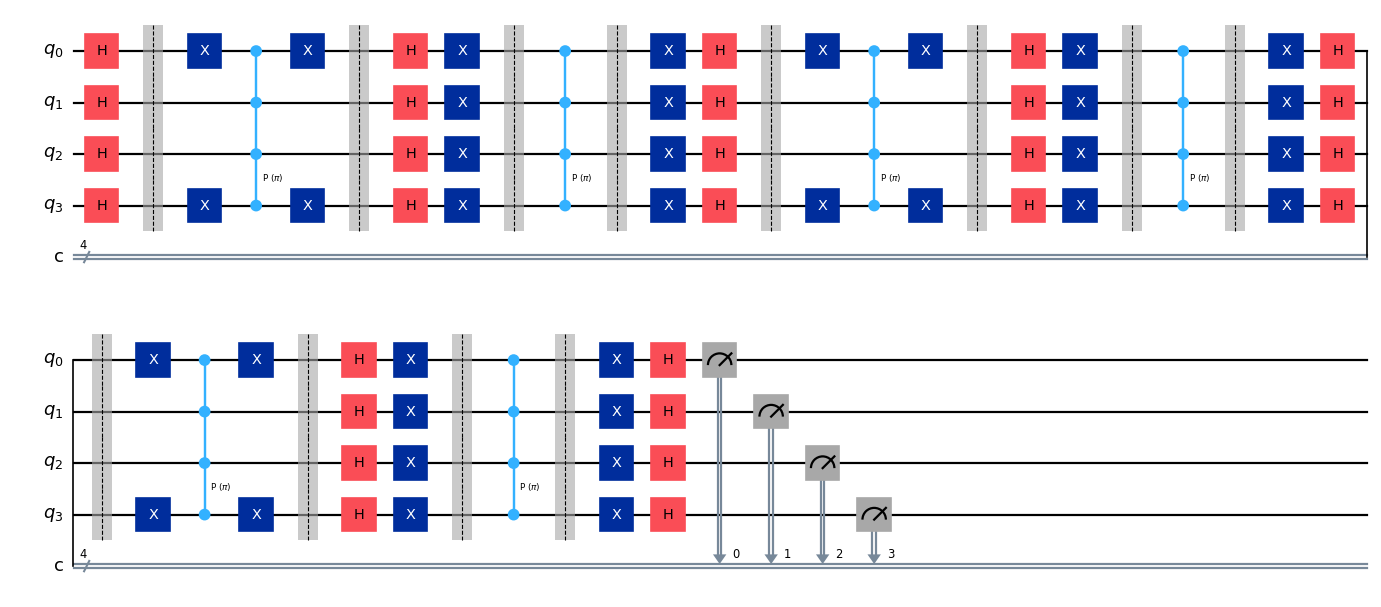

In [17]:
num_qubits = 4
secret_pin = 6

def get_password_binary(pin: int, qubits: int) -> str:
    return format(pin, f'0{qubits}b')

hidden_password = get_password_binary(secret_pin, num_qubits)

print(f"--- Quantum PIN Cracker Setup ---")
print(f"Target PIN: {secret_pin} | Binary: {hidden_password}")

def password_cracker_oracle(qc: QuantumCircuit, qbits: int):
    # Handle Qiskit little-endianness
    target = hidden_password[::-1]

    for i, bit in enumerate(target):
        if bit == '0':
            qc.x(i)

    qc.mcp(np.pi, list(range(qbits - 1)), qbits - 1)

    for i, bit in enumerate(target):
        if bit == '0':
            qc.x(i)

grover_cracker = GroverAlgorithm(num_qubits, password_cracker_oracle)
crack_circuit = grover_cracker.build_circuit()
grover_cracker.draw_pretty()

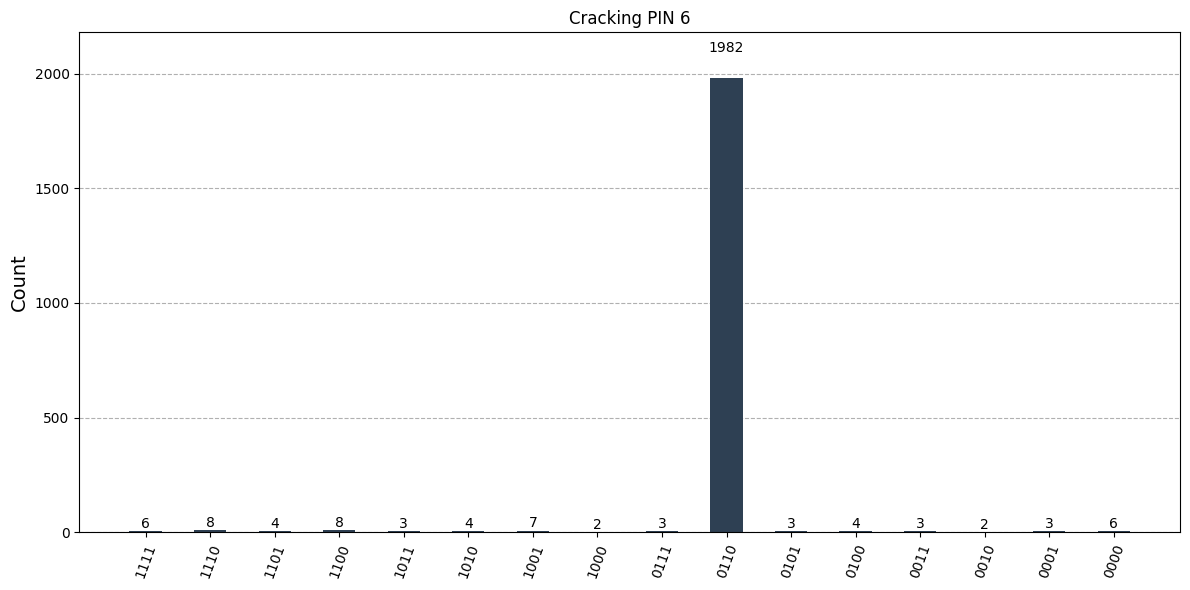

In [18]:
def run_grover(grover_obj, mode="plot", title="Results"):
    """
    Flexible execution:
    mode='plot' for histogram,
    mode='draw' for circuit visualization
    """
    circuit = grover_obj.qc

    if mode == "draw":
        return grover_obj.draw_pretty()

    simulator = AerSimulator()
    counts = simulator.run(circuit, shots=2048).result().get_counts()

    return plot_histogram(counts, figsize=(12, 6), color=['#2e4053'],
                          title=title, sort='desc', bar_labels=True)

# Test with the PIN Cracker
run_grover(grover_cracker, mode="plot", title=f"Cracking PIN {secret_pin}")